# KNN Hyperparameter Tuning 

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

sns.set_style('whitegrid')

## 1. Load the data

In [2]:
df = pd.read_csv('wine.csv')
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,1,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,1,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,1,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
X = df.drop('Wine', axis=1)
y = df['Wine']

X.shape, y.value_counts()

((178, 13),
 Wine
 2    71
 1    59
 3    48
 Name: count, dtype: int64)

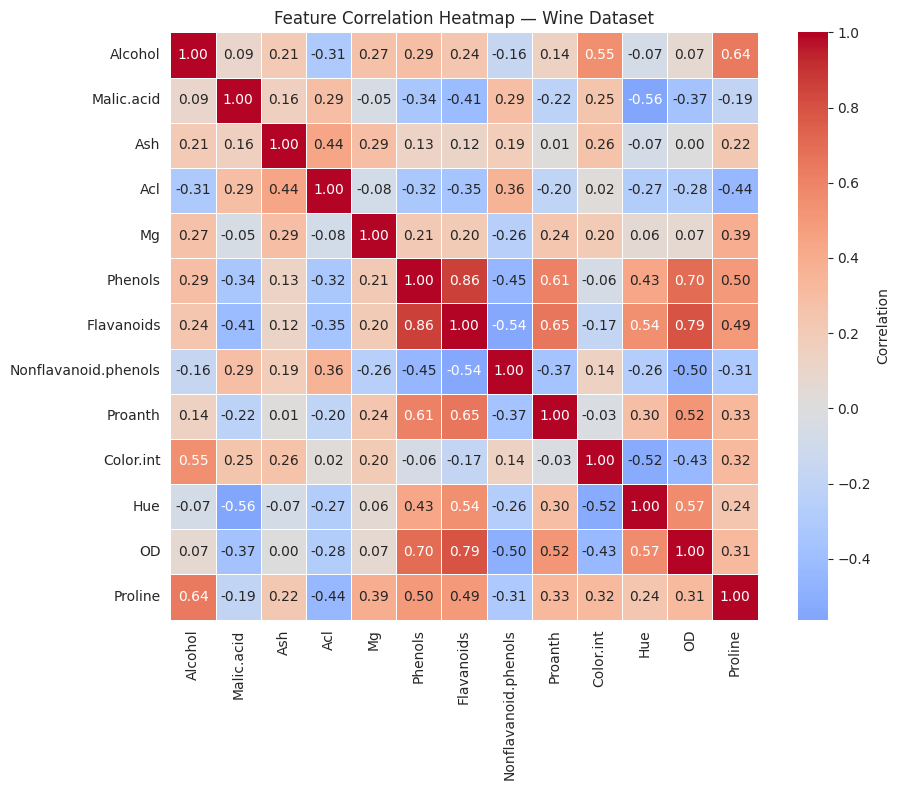

In [4]:
plt.figure(figsize=(10, 8))
corr_matrix = X.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Feature Correlation Heatmap — Wine Dataset')
plt.tight_layout()
plt.show()

## 2. Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((142, 13), (36, 13))

## 3. diff values

In [6]:
manual_results = {}

In [7]:
#Group A
k_values = [1, 5, 7, 9, 11, 13, 15]

grid_A = GridSearchCV(
    estimator=Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
    param_grid={'knn__n_neighbors': k_values},
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_A.fit(X_train, y_train)

results_A = pd.DataFrame(grid_A.cv_results_)
fold_cols_A = [c for c in results_A.columns if c.startswith('split') and c.endswith('_test_score')]
matrix_A = results_A.set_index('param_knn__n_neighbors')[fold_cols_A]
matrix_A.columns = [f'Fold {i+1}' for i in range(len(fold_cols_A))]
matrix_A['mean'] = results_A.set_index('param_knn__n_neighbors')['mean_test_score']

#best mean 
manual_results.update(results_A.set_index('param_knn__n_neighbors')['mean_test_score'].to_dict())

matrix_A

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,mean
param_knn__n_neighbors,,,,,,
1,0.931034,0.931034,0.928571,0.928571,0.964286,0.936700
5,1.000000,0.896552,0.964286,0.964286,1.000000,0.965025
7,0.965517,0.896552,0.928571,1.000000,0.964286,0.950985
9,1.000000,0.896552,0.964286,0.964286,1.000000,0.965025
11,1.000000,0.896552,0.964286,1.000000,1.000000,0.972167
13,1.000000,0.896552,0.964286,0.964286,1.000000,0.965025
15,1.000000,0.896552,0.964286,1.000000,1.000000,0.972167


In [8]:
#Group B 
k_values = [2, 4, 6, 8, 10, 12, 14]

grid_B = GridSearchCV(
    estimator=Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
    param_grid={'knn__n_neighbors': k_values},
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_B.fit(X_train, y_train)

results_B = pd.DataFrame(grid_B.cv_results_)
fold_cols_B = [c for c in results_B.columns if c.startswith('split') and c.endswith('_test_score')]
matrix_B = results_B.set_index('param_knn__n_neighbors')[fold_cols_B]
matrix_B.columns = [f'Fold {i+1}' for i in range(len(fold_cols_B))]
matrix_B['mean'] = results_B.set_index('param_knn__n_neighbors')['mean_test_score']

#best mean score
manual_results.update(results_B.set_index('param_knn__n_neighbors')['mean_test_score'].to_dict())

matrix_B

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,mean
param_knn__n_neighbors,,,,,,
2,0.896552,0.931034,0.928571,1.000000,0.964286,0.944089
4,0.896552,0.965517,0.892857,1.000000,0.964286,0.943842
6,0.931034,0.896552,0.964286,1.000000,0.964286,0.951232
8,0.965517,0.896552,0.964286,1.000000,0.964286,0.958128
10,1.000000,0.896552,0.964286,1.000000,1.000000,0.972167
12,1.000000,0.896552,0.964286,0.964286,1.000000,0.965025
14,1.000000,0.896552,0.964286,1.000000,1.000000,0.972167


In [9]:
# Group C 
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

grid_C = GridSearchCV(
    estimator=Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
    param_grid={'knn__n_neighbors': k_values},
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_C.fit(X_train, y_train)

results_C = pd.DataFrame(grid_C.cv_results_)
fold_cols_C = [c for c in results_C.columns if c.startswith('split') and c.endswith('_test_score')]
matrix_C = results_C.set_index('param_knn__n_neighbors')[fold_cols_C]
matrix_C.columns = [f'Fold {i+1}' for i in range(len(fold_cols_C))]
matrix_C['mean'] = results_C.set_index('param_knn__n_neighbors')['mean_test_score']

#best mean score 
manual_results.update(results_C.set_index('param_knn__n_neighbors')['mean_test_score'].to_dict())

matrix_C

,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,mean
param_knn__n_neighbors,,,,,,
1,0.931034,0.931034,0.928571,0.928571,0.964286,0.936700
2,0.896552,0.931034,0.928571,1.000000,0.964286,0.944089
3,0.896552,0.931034,0.964286,1.000000,0.964286,0.951232
4,0.896552,0.965517,0.892857,1.000000,0.964286,0.943842
5,1.000000,0.896552,0.964286,0.964286,1.000000,0.965025
6,0.931034,0.896552,0.964286,1.000000,0.964286,0.951232
7,0.965517,0.896552,0.928571,1.000000,0.964286,0.950985
8,0.965517,0.896552,0.964286,1.000000,0.964286,0.958128
9,1.000000,0.896552,0.964286,0.964286,1.000000,0.965025


Best-performing group: Group A [1,5,7,9,11,13,15]


,best_mean_accuracy,best_n_neighbors
"Group A [1,5,7,9,11,13,15]",0.972167,11.0
"Group B [2,4,6,8,10,12,14]",0.972167,10.0
Group C [1-10],0.972167,10.0


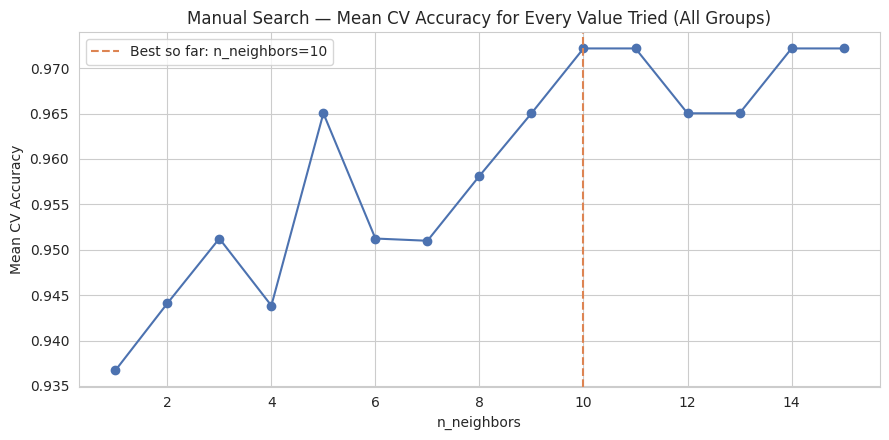

In [10]:
# combined results table
manual_df = pd.Series(manual_results, name='mean_cv_accuracy').sort_index()
manual_df = manual_df.to_frame()
manual_df['rank'] = manual_df['mean_cv_accuracy'].rank(ascending=False, method='min').astype(int)

# three groups against each other
group_summary = pd.DataFrame({
    'Group A [1,5,7,9,11,13,15]':  [matrix_A['mean'].max(), matrix_A['mean'].idxmax()],
    'Group B [2,4,6,8,10,12,14]':  [matrix_B['mean'].max(), matrix_B['mean'].idxmax()],
    'Group C [1-10]':              [matrix_C['mean'].max(), matrix_C['mean'].idxmax()],
}, index=['best_mean_accuracy', 'best_n_neighbors']).T

best_group = group_summary['best_mean_accuracy'].idxmax()
print(f"Best-performing group: {best_group}")
display(group_summary)

plt.figure(figsize=(9, 4.5))
plt.plot(manual_df.index, manual_df['mean_cv_accuracy'], marker='o', color='#4C72B0')
best_manual_k = manual_df['mean_cv_accuracy'].idxmax()
plt.axvline(best_manual_k, color='#DD8452', linestyle='--', label=f'Best so far: n_neighbors={best_manual_k}')
plt.title('Manual Search — Mean CV Accuracy for Every Value Tried (All Groups)')
plt.xlabel('n_neighbors')
plt.ylabel('Mean CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

### Best value of n_neighbors

In [11]:
best_k = manual_df['mean_cv_accuracy'].idxmax()
best_score = manual_df.loc[best_k, 'mean_cv_accuracy']

print(f"Best n_neighbors across all manual groups: {best_k}")
print(f"Best mean CV accuracy: {best_score:.4f}")

Best n_neighbors across all manual groups: 10
Best mean CV accuracy: 0.9722


## 6. Best model 

In [12]:
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Test accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
print()
print(classification_report(y_test, y_pred))

Test accuracy: 1.0000

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



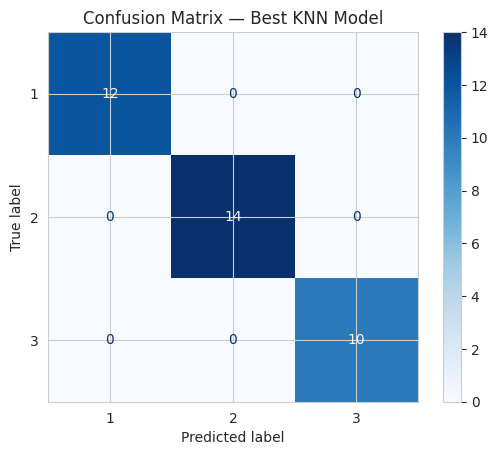

In [13]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix — Best KNN Model')
plt.show()

## 7. Save

In [14]:
joblib.dump(best_model, 'best_knn_model.joblib')
print("Saved best model (n_neighbors={}) to best_knn_model.joblib".format(best_k))

Saved best model (n_neighbors=10) to best_knn_model.joblib
